<a href="https://colab.research.google.com/github/Deehasajose/TB-Detection-/blob/main/Untitled0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install torch torchvision transformers datasets

KeyboardInterrupt: 

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import zipfile
zip_path = '/content/drive/MyDrive/TB PROJECT/Chest X-ray Dataset for Tuberculosis Segmentation.zip'
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall('/content/tb_dataset')

# 3. Check your files loaded correctly
import os
print(os.listdir('/content/tb_dataset'))

['Chest-X-Ray', 'MetaData.csv']


### 4. Explore Dataset Structure and Metadata

Before training a model, it's crucial to understand the dataset's organization and content. We'll inspect the directory structure of the extracted images and load the `MetaData.csv` file to examine labels and other relevant information.

In [ ]:
import os
import pandas as pd

dataset_base_path = '/content/tb_dataset/'
chest_xray_path = os.path.join(dataset_base_path, 'Chest-X-Ray')

# List contents of the Chest-X-Ray directory
print('Contents of Chest-X-Ray directory:')
for root, dirs, files in os.walk(chest_xray_path):
    level = root.replace(chest_xray_path, '').count(os.sep)
    indent = ' ' * 4 * (level)
    print(f'{indent}{os.path.basename(root)}/')
    subindent = ' ' * 4 * (level + 1)
    for f in files:
        print(f'{subindent}{f}')

# Load and display the metadata CSV
metadata_path = os.path.join(dataset_base_path, 'MetaData.csv')
if os.path.exists(metadata_path):
    metadata_df = pd.read_csv(metadata_path)
    print('\nMetadata DataFrame Info:')
    metadata_df.info()
    print('\nFirst 5 rows of Metadata:')
    display(metadata_df.head())
    print("\nValue counts for 'ptb' column:")
    display(metadata_df['ptb'].value_counts())
else:
    print(f'MetaData.csv not found at {metadata_path}')

Contents of Chest-X-Ray directory:
Chest-X-Ray/
    Chest-X-Ray/
        image/
            1183.png
            1593.png
            1115.png
            1605.png
            1479.png
            1458.png
            1504.png
            1545.png
            1007.png
            1376.png
            1056.png
            1590.png
            1406.png
            1602.png
            1393.png
            1609.png
            1530.png
            1013.png
            1313.png
            1678.png
            1575.png
            1198.png
            1439.png
            1040.png
            1350.png
            1395.png
            1637.png
            1264.png
            1505.png
            1234.png
            1302.png
            1197.png
            1615.png
            1035.png
            1026.png
            1317.png
            1330.png
            1133.png
            1351.png
            1433.png
            1304.png
            1660.png
            1272.png
            1514.

,id,gender,age,county,ptb,remarks
0,1000,male,31,Shenxhen,0,normal
1,1001,male,64,Shenxhen,0,normal
2,1002,male,35,Shenxhen,0,normal
3,1003,male,32,Shenxhen,1,"STB,ATB,tuberculosis pleuritis"
4,1004,male,2,Shenxhen,1,secondary PTB in the bilateral upper field



Value counts for 'ptb' column:


,count
ptb,
0,359
1,345


### 5. Data Preparation for CNN Training

In [ ]:
import os
import pandas as pd
import glob

dataset_base_path = '/content/tb_dataset/'
chest_xray_path = os.path.join(dataset_base_path, 'Chest-X-Ray')
metadata_path = os.path.join(dataset_base_path, 'MetaData.csv')

# Load and display the metadata CSV
metadata_df = pd.read_csv(metadata_path)

# Create a list of all image paths
# The structure within the zip is Chest-X-Ray/Chest-X-Ray/image/*.png
image_paths = glob.glob(os.path.join(chest_xray_path, 'Chest-X-Ray', 'image', '*.png'))

# Create a DataFrame from image paths
image_df = pd.DataFrame({'path': image_paths})

# Extract image ID from the filename
image_df['id'] = image_df['path'].apply(lambda x: int(os.path.basename(x).replace('.png', '')))

# Merge image paths with metadata_df
data_df = pd.merge(image_df, metadata_df, on='id', how='left')

print('Combined DataFrame Info:')
data_df.info()
print('\nFirst 5 rows of Combined DataFrame:')
display(data_df.head())

Combined DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 704 entries, 0 to 703
Data columns (total 7 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   path     704 non-null    object
 1   id       704 non-null    int64 
 2   gender   704 non-null    object
 3   age      704 non-null    object
 4   county   704 non-null    object
 5   ptb      704 non-null    int64 
 6   remarks  699 non-null    object
dtypes: int64(2), object(5)
memory usage: 38.6+ KB

First 5 rows of Combined DataFrame:


,path,id,gender,age,county,ptb,remarks
0,/content/tb_dataset/Chest-X-Ray/Chest-X-Ray/im...,1183,female,25,Shenxhen,1,Right PTB
1,/content/tb_dataset/Chest-X-Ray/Chest-X-Ray/im...,1593,F,044,Montgomery,0,normal
2,/content/tb_dataset/Chest-X-Ray/Chest-X-Ray/im...,1115,female,40,Shenxhen,1,"STB,NATB"
3,/content/tb_dataset/Chest-X-Ray/Chest-X-Ray/im...,1605,M,053,Montgomery,0,normal
4,/content/tb_dataset/Chest-X-Ray/Chest-X-Ray/im...,1479,male,63,Shenxhen,1,bilateral PTB


#### 5.1 Splitting the Data into Training and Validation Sets

In [ ]:
from sklearn.model_selection import train_test_split

# Split data into training and validation sets
train_df, val_df = train_test_split(data_df, test_size=0.2, random_state=42, stratify=data_df['ptb'])

print(f'Training samples: {len(train_df)}')
print(f'Validation samples: {len(val_df)}')

print('\nTraining Set Label Distribution:')
display(train_df['ptb'].value_counts())

print('\nValidation Set Label Distribution:')
display(val_df['ptb'].value_counts())

Training samples: 563
Validation samples: 141

Training Set Label Distribution:


,count
ptb,
0,287
1,276



Validation Set Label Distribution:


,count
ptb,
0,72
1,69


#### 5.2 Defining Image Transformations

In [ ]:
import torchvision.transforms as transforms

# Define image transformations
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),  # Resize images to 224x224 for common CNN architectures
    transforms.Grayscale(num_output_channels=3), # Convert to 3 channels (RGB) for pre-trained models
    transforms.ToTensor(),          # Convert images to PyTorch tensors
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) # ImageNet normalization
])

val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

#### 5.3 Creating Custom Dataset and DataLoader

In [ ]:
from torch.utils.data import Dataset, DataLoader
from PIL import Image

class ChestXRayDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        img_path = self.dataframe.iloc[idx]['path']
        image = Image.open(img_path).convert('L') # Open as grayscale
        label = self.dataframe.iloc[idx]['ptb']

        if self.transform:
            image = self.transform(image)

        return image, label

# Create dataset instances
train_dataset = ChestXRayDataset(train_df, transform=train_transforms)
val_dataset = ChestXRayDataset(val_df, transform=val_transforms)

# Create DataLoader instances
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

print(f'Number of training batches: {len(train_loader)}')
print(f'Number of validation batches: {len(val_loader)}')

# Verify a batch
for images, labels in train_loader:
    print(f'Batch image shape: {images.shape}')
    print(f'Batch label shape: {labels.shape}')
    break

Number of training batches: 18
Number of validation batches: 5
Batch image shape: torch.Size([32, 3, 224, 224])
Batch label shape: torch.Size([32])


### 6. Defining the CNN Model

In [ ]:
import torch
import torch.nn as nn
import torchvision.models as models

# Load a pre-trained ResNet-18 model
model = models.resnet18(pretrained=True)

# Freeze all parameters in the network
for param in model.parameters():
    param.requires_grad = False

# Modify the final classification layer for binary classification (2 classes: TB or not TB)
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, 2)  # Output 2 classes: 0 or 1

# Move the model to GPU if available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)

print('Model Architecture:')
print(model)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
100%|██████████| 44.7M/44.7M [00:00<00:00, 171MB/s]


Model Architecture:
ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): R

### 7. Training the CNN Model

In [ ]:
import torch.optim as optim

# Define loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.fc.parameters(), lr=0.001) # Only optimize the new classification layer

# Training loop
num_epochs = 10

for epoch in range(num_epochs):
    model.train() # Set model to training mode
    running_loss = 0.0
    correct_predictions = 0
    total_samples = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs.data, 1)
        total_samples += labels.size(0)
        correct_predictions += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(train_dataset)
    epoch_accuracy = correct_predictions / total_samples

    print(f'Epoch {epoch+1}/{num_epochs}, Loss: {epoch_loss:.4f}, Accuracy: {epoch_accuracy:.4f}')

    # Validation phase
    model.eval() # Set model to evaluation mode
    val_running_loss = 0.0
    val_correct_predictions = 0
    val_total_samples = 0

    with torch.no_grad(): # Disable gradient calculation for validation
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            val_running_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs.data, 1)
            val_total_samples += labels.size(0)
            val_correct_predictions += (predicted == labels).sum().item()

    val_loss = val_running_loss / len(val_dataset)
    val_accuracy = val_correct_predictions / val_total_samples

    print(f'Validation Loss: {val_loss:.4f}, Validation Accuracy: {val_accuracy:.4f}')

print('\nTraining Complete!')

Epoch 1/10, Loss: 0.6627, Accuracy: 0.6075
Validation Loss: 0.7161, Validation Accuracy: 0.5532
Epoch 2/10, Loss: 0.5244, Accuracy: 0.7460
Validation Loss: 0.6822, Validation Accuracy: 0.6099
Epoch 3/10, Loss: 0.4808, Accuracy: 0.7904
Validation Loss: 0.5634, Validation Accuracy: 0.7376
Epoch 4/10, Loss: 0.4597, Accuracy: 0.7975
Validation Loss: 0.5540, Validation Accuracy: 0.7447
Epoch 5/10, Loss: 0.4434, Accuracy: 0.8135
Validation Loss: 0.5486, Validation Accuracy: 0.7730
Epoch 6/10, Loss: 0.4186, Accuracy: 0.8224
Validation Loss: 0.5451, Validation Accuracy: 0.7447
Epoch 7/10, Loss: 0.4046, Accuracy: 0.8242
Validation Loss: 0.5441, Validation Accuracy: 0.7447
Epoch 8/10, Loss: 0.3977, Accuracy: 0.8242
Validation Loss: 0.5464, Validation Accuracy: 0.7518
Epoch 9/10, Loss: 0.3880, Accuracy: 0.8401
Validation Loss: 0.5271, Validation Accuracy: 0.7660
Epoch 10/10, Loss: 0.3819, Accuracy: 0.8526
Validation Loss: 0.5269, Validation Accuracy: 0.7660

Training Complete!


### 6. Defining the CNN Model

In [ ]:
import torch
import torch.nn as nn
import torchvision.models as models

# Load a pre-trained ResNet-18 model
model = models.resnet18(pretrained=True)

# Freeze all parameters in the network
for param in model.parameters():
    param.requires_grad = False

# Modify the final classification layer for binary classification (2 classes: TB or not TB)
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, 2)  # Output 2 classes: 0 or 1

# Move the model to GPU if available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)

print('Model Architecture:')
print(model)

Model Architecture:
ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): R

### 7. Training

In [ ]:
import torch.optim as optim

# Define loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.fc.parameters(), lr=0.001) # Only optimize the new classification layer

# Training loop
num_epochs = 10

for epoch in range(num_epochs):
    model.train() # Set model to training mode
    running_loss = 0.0
    correct_predictions = 0
    total_samples = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs.data, 1)
        total_samples += labels.size(0)
        correct_predictions += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(train_dataset)
    epoch_accuracy = correct_predictions / total_samples

    print(f'Epoch {epoch+1}/{num_epochs}, Loss: {epoch_loss:.4f}, Accuracy: {epoch_accuracy:.4f}')

    # Validation phase
    model.eval() # Set model to evaluation mode
    val_running_loss = 0.0
    val_correct_predictions = 0
    val_total_samples = 0

    with torch.no_grad(): # Disable gradient calculation for validation
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            val_running_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs.data, 1)
            val_total_samples += labels.size(0)
            val_correct_predictions += (predicted == labels).sum().item()

    val_loss = val_running_loss / len(val_dataset)
    val_accuracy = val_correct_predictions / val_total_samples

    print(f'Validation Loss: {val_loss:.4f}, Validation Accuracy: {val_accuracy:.4f}')

print('\nTraining Complete!')

Epoch 1/10, Loss: 0.6139, Accuracy: 0.6572
Validation Loss: 0.7113, Validation Accuracy: 0.5390
Epoch 2/10, Loss: 0.5203, Accuracy: 0.7691
Validation Loss: 0.6441, Validation Accuracy: 0.6383
Epoch 3/10, Loss: 0.4995, Accuracy: 0.7798
Validation Loss: 0.5737, Validation Accuracy: 0.6879
Epoch 4/10, Loss: 0.4596, Accuracy: 0.7957
Validation Loss: 0.6109, Validation Accuracy: 0.6312
Epoch 5/10, Loss: 0.4431, Accuracy: 0.8028
Validation Loss: 0.5676, Validation Accuracy: 0.7163
Epoch 6/10, Loss: 0.4249, Accuracy: 0.8259
Validation Loss: 0.5500, Validation Accuracy: 0.7092
Epoch 7/10, Loss: 0.4179, Accuracy: 0.8206
Validation Loss: 0.5323, Validation Accuracy: 0.7518
Epoch 8/10, Loss: 0.4105, Accuracy: 0.8313
Validation Loss: 0.5407, Validation Accuracy: 0.7092
Epoch 9/10, Loss: 0.4103, Accuracy: 0.8259
Validation Loss: 0.5572, Validation Accuracy: 0.6809
Epoch 10/10, Loss: 0.4133, Accuracy: 0.8295
Validation Loss: 0.5189, Validation Accuracy: 0.7376

Training Complete!


### 6. Defining the CNN Model

In [ ]:
import torch
import torch.nn as nn
import torchvision.models as models

# Load a pre-trained ResNet-18 model
model = models.resnet18(pretrained=True)

# Freeze all parameters in the network
for param in model.parameters():
    param.requires_grad = False

# Modify the final classification layer for binary classification (2 classes: TB or not TB)
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, 2)  # Output 2 classes: 0 or 1

# Move the model to GPU if available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)

print('Model Architecture:')
print(model)

Model Architecture:
ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): R

### 7. Training the Model

In [ ]:
import torch
import torch.nn as nn
import torchvision.models as models
import torch.optim as optim
import pandas as pd
import glob
import os
from PIL import Image
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
from sklearn.model_selection import train_test_split
import zipfile
import shutil

# --- Ensure Model and Device are Defined ---
if 'model' not in locals():
    model = models.resnet18(pretrained=True)
    for param in model.parameters():
        param.requires_grad = False
    num_ftrs = model.fc.in_features
    model.fc = nn.Linear(num_ftrs, 2)  # Output 2 classes: 0 or 1
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = model.to(device)
elif 'device' not in locals():
    # If model is defined but device might have been lost
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = model.to(device) # Ensure model is on the correct device if device was re-established

# --- Ensure DataLoaders and their dependencies are Defined ---
# This block re-initializes data loading components if they are not found,
# making the training cell robust against kernel restarts or out-of-order execution.
if 'train_loader' not in locals() or 'val_loader' not in locals():
    dataset_base_path = '/content/tb_dataset/'
    chest_xray_base_dir = os.path.join(dataset_base_path, 'Chest-X-Ray')
    # Corrected path for image directory based on previous `os.walk` output
    chest_xray_image_dir = os.path.join(chest_xray_base_dir, 'Chest-X-Ray', 'image')
    metadata_path = os.path.join(dataset_base_path, 'MetaData.csv')
    zip_path = '/content/drive/MyDrive/TB PROJECT/Chest X-ray Dataset for Tuberculosis Segmentation.zip'

    # Ensure dataset is extracted
    if not os.path.exists(metadata_path) or not os.path.isdir(chest_xray_image_dir):
        print("Dataset not found or partially extracted. Attempting to re-extract.")
        try:
            if os.path.exists(dataset_base_path):
                shutil.rmtree(dataset_base_path)
                print(f"Removed existing partial directory: {dataset_base_path}")
            os.makedirs(dataset_base_path, exist_ok=True)
            with zipfile.ZipFile(zip_path, 'r') as zip_ref:
                zip_ref.extractall(dataset_base_path)
            print("Dataset re-extracted successfully.")
        except Exception as e:
            raise RuntimeError(f"Failed to re-extract dataset from {zip_path}: {e}. Please ensure the zip file is accessible and correct.")

    # Now that extraction is ensured, proceed with loading components.
    # These variables are unconditionally defined if train_loader/val_loader are not in locals.

    # Load metadata
    metadata_df = pd.read_csv(metadata_path)

    # Create data_df
    image_paths = glob.glob(os.path.join(chest_xray_image_dir, '*.png'))
    image_df = pd.DataFrame({'path': image_paths})
    image_df['id'] = image_df['path'].apply(lambda x: int(os.path.basename(x).replace('.png', '')))
    data_df = pd.merge(image_df, metadata_df, on='id', how='left')

    # Split data
    train_df, val_df = train_test_split(data_df, test_size=0.2, random_state=42, stratify=data_df['ptb'])

    # Define transforms
    train_transforms = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.Grayscale(num_output_channels=3),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

    val_transforms = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.Grayscale(num_output_channels=3),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

    # Define ChestXRayDataset class
    class ChestXRayDataset(Dataset):
        def __init__(self, dataframe, transform=None):
            self.dataframe = dataframe
            self.transform = transform

        def __len__(self):
            return len(self.dataframe)

        def __getitem__(self, idx):
            img_path = self.dataframe.iloc[idx]['path']
            image = Image.open(img_path).convert('L') # Open as grayscale
            label = self.dataframe.iloc[idx]['ptb']

            if self.transform:
                image = self.transform(image)
            return image, label

    # Create dataset instances
    train_dataset = ChestXRayDataset(train_df, transform=train_transforms)
    val_dataset = ChestXRayDataset(val_df, transform=val_transforms)

    # Create DataLoader instances
    batch_size = 32
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)


# Define loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.fc.parameters(), lr=0.001) # Only optimize the new classification layer

# Training loop
num_epochs = 30

for epoch in range(num_epochs):
    model.train() # Set model to training mode
    running_loss = 0.0
    correct_predictions = 0
    total_samples = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs.data, 1)
        total_samples += labels.size(0)
        correct_predictions += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(train_loader.dataset)
    epoch_accuracy = correct_predictions / total_samples

    print(f'Epoch {epoch+1}/{num_epochs}, Loss: {epoch_loss:.4f}, Accuracy: {epoch_accuracy:.4f}')

    # Validation phase
    model.eval() # Set model to evaluation mode
    val_running_loss = 0.0
    val_correct_predictions = 0
    val_total_samples = 0

    with torch.no_grad(): # Disable gradient calculation for validation
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            val_running_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs.data, 1)
            val_total_samples += labels.size(0)
            val_correct_predictions += (predicted == labels).sum().item()

    val_loss = val_running_loss / len(val_loader.dataset)
    val_accuracy = val_correct_predictions / val_total_samples

    print(f'Validation Loss: {val_loss:.4f}, Validation Accuracy: {val_accuracy:.4f}')

print('\nTraining Complete!')

Epoch 1/30, Loss: 0.6726, Accuracy: 0.6039
Validation Loss: 0.6719, Validation Accuracy: 0.6028
Epoch 2/30, Loss: 0.6175, Accuracy: 0.6554
Validation Loss: 0.6029, Validation Accuracy: 0.6667
Epoch 3/30, Loss: 0.5929, Accuracy: 0.6909
Validation Loss: 0.5747, Validation Accuracy: 0.7092
Epoch 4/30, Loss: 0.5744, Accuracy: 0.7194
Validation Loss: 0.5495, Validation Accuracy: 0.7305
Epoch 5/30, Loss: 0.5551, Accuracy: 0.7442
Validation Loss: 0.5580, Validation Accuracy: 0.7376
Epoch 6/30, Loss: 0.5153, Accuracy: 0.7513
Validation Loss: 0.5367, Validation Accuracy: 0.7376
Epoch 7/30, Loss: 0.5351, Accuracy: 0.7549
Validation Loss: 0.5294, Validation Accuracy: 0.7163
Epoch 8/30, Loss: 0.5250, Accuracy: 0.7371
Validation Loss: 0.5186, Validation Accuracy: 0.7660
Epoch 9/30, Loss: 0.5223, Accuracy: 0.7336
Validation Loss: 0.5417, Validation Accuracy: 0.7305
Epoch 10/30, Loss: 0.5349, Accuracy: 0.7407
Validation Loss: 0.4961, Validation Accuracy: 0.7801
Epoch 11/30, Loss: 0.5019, Accuracy: 0.

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# 1. Put model in evaluation mode and gather all predictions
# Use 'trained_final_model' from the final training cell
trained_final_model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        outputs = trained_final_model(images)
        _, predicted = torch.max(outputs, 1)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

# 2. Compute the confusion matrix
cm = confusion_matrix(all_labels, all_preds)

# 3. Plot the confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal (0)', 'TB (1)'],
            yticklabels=['Normal (0)', 'TB (1)'])
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.title('Confusion Matrix - Validation Set')
plt.show()

# 4. Print detailed metrics (Precision, Recall, F1-score)
print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=['Normal', 'TB']))

NameError: name 'trained_final_model' is not defined

In [ ]:
import torch.optim as optim

def train_model(model, train_loader, val_loader, num_epochs, learning_rate, device):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.fc.parameters(), lr=learning_rate)

    best_val_accuracy = 0.0

    for epoch in range(num_epochs):
        model.train() # Set model to training mode
        running_loss = 0.0
        correct_predictions = 0
        total_samples = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs.data, 1)
            total_samples += labels.size(0)
            correct_predictions += (predicted == labels).sum().item()

        epoch_loss = running_loss / len(train_loader.dataset)
        epoch_accuracy = correct_predictions / total_samples

        # Validation phase
        model.eval() # Set model to evaluation mode
        val_running_loss = 0.0
        val_correct_predictions = 0
        val_total_samples = 0

        with torch.no_grad(): # Disable gradient calculation for validation
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)

                val_running_loss += loss.item() * images.size(0)
                _, predicted = torch.max(outputs.data, 1)
                val_total_samples += labels.size(0)
                val_correct_predictions += (predicted == labels).sum().item()

        val_loss = val_running_loss / len(val_loader.dataset)
        val_accuracy = val_correct_predictions / val_total_samples

        print(f'Epoch {epoch+1}/{num_epochs}, Train Loss: {epoch_loss:.4f}, Train Acc: {epoch_accuracy:.4f}, Val Loss: {val_loss:.4f}, Val Acc: {val_accuracy:.4f}')

        # Keep track of the best validation accuracy
        if val_accuracy > best_val_accuracy:
            best_val_accuracy = val_accuracy

    return best_val_accuracy

In [ ]:
import torchvision.models as models
import torch.nn as nn
import torch
import os
import pandas as pd
import glob
from PIL import Image
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
from sklearn.model_selection import train_test_split
import zipfile
import torch.optim as optim

# --- 1. Infrastructure Setup ---
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# --- 2. Helper Function for Training ---
def train_model(model, train_loader, val_loader, num_epochs, learning_rate, device):
    criterion = nn.CrossEntropyLoss()
    # FIX: Added L2 Regularization (weight_decay=1e-4) to penalize large weights and stop overfitting
    optimizer = optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=learning_rate,
        weight_decay=1e-4
    )

    # FIX: Adding a learning rate scheduler to lower the learning rate dynamically when validation stalls
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.2, patience=2, verbose=True)

    best_val_accuracy = 0.0
    train_losses = []
    train_accuracies = []
    val_losses = []
    val_accuracies = []

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        correct_predictions = 0
        total_samples = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs.data, 1)
            total_samples += labels.size(0)
            correct_predictions += (predicted == labels).sum().item()

        epoch_train_loss = running_loss / len(train_loader.dataset)
        epoch_train_accuracy = correct_predictions / total_samples
        train_losses.append(epoch_train_loss)
        train_accuracies.append(epoch_train_accuracy)

        model.eval()
        val_running_loss = 0.0
        val_correct_predictions = 0
        val_total_samples = 0

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)

                val_running_loss += loss.item() * images.size(0)
                _, predicted = torch.max(outputs.data, 1)
                val_total_samples += labels.size(0)
                val_correct_predictions += (predicted == labels).sum().item()

        epoch_val_loss = val_running_loss / len(val_loader.dataset)
        epoch_val_accuracy = val_correct_predictions / val_total_samples
        val_losses.append(epoch_val_loss)
        val_accuracies.append(epoch_val_accuracy)

        # Step the scheduler based on validation accuracy performance
        scheduler.step(epoch_val_accuracy)

        if epoch_val_accuracy > best_val_accuracy:
            best_val_accuracy = epoch_val_accuracy

        print(f'   Epoch {epoch+1}/{num_epochs} - Train Loss: {epoch_train_loss:.4f}, Train Acc: {epoch_train_accuracy:.4f}, Val Loss: {epoch_val_loss:.4f}, Val Acc: {epoch_val_accuracy:.4f}')

    return best_val_accuracy, train_losses, train_accuracies, val_losses, val_accuracies, model

# --- 3. Data Re-initialization ---
if 'train_loader' not in locals() or 'val_loader' not in locals():
    print("Re-initializing data pipeline...")
    dataset_base_path = '/content/tb_dataset/'
    zip_path = '/content/drive/MyDrive/TB PROJECT/Chest X-ray Dataset for Tuberculosis Segmentation.zip'
    if not os.path.exists(dataset_base_path):
        os.makedirs(dataset_base_path, exist_ok=True)
        with zipfile.ZipFile(zip_path, 'r') as zip_ref: zip_ref.extractall(dataset_base_path)

    chest_xray_image_dir = os.path.join(dataset_base_path, 'Chest-X-Ray', 'Chest-X-Ray', 'image')
    metadata_df = pd.read_csv(os.path.join(dataset_base_path, 'MetaData.csv'))
    image_paths = glob.glob(os.path.join(chest_xray_image_dir, '*.png'))
    image_df = pd.DataFrame({'path': image_paths})
    image_df['id'] = image_df['path'].apply(lambda x: int(os.path.basename(x).replace('.png', '')))
    data_df = pd.merge(image_df, metadata_df, on='id', how='left')
    train_df, val_df = train_test_split(data_df, test_size=0.2, random_state=42, stratify=data_df['ptb'])

    # FIX: Enhanced data augmentation specifically tailored for structure-sensitive chest X-rays
    train_transforms = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(15),    # Increased rotation flexibility
        transforms.RandomAffine(degrees=0, translate=(0.05, 0.05)), # Simulates varying patient positions
        transforms.Grayscale(num_output_channels=3),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

    val_transforms = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.Grayscale(num_output_channels=3),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

    class ChestXRayDataset(Dataset):
        def __init__(self, dataframe, transform=None):
            self.dataframe = dataframe
            self.transform = transform
        def __len__(self): return len(self.dataframe)
        def __getitem__(self, idx):
            img_path = self.dataframe.iloc[idx]['path']
            image = Image.open(img_path).convert('L')
            label = self.dataframe.iloc[idx]['ptb']
            if self.transform: image = self.transform(image)
            return image, label

    train_loader = DataLoader(ChestXRayDataset(train_df, transform=train_transforms), batch_size=32, shuffle=True)
    val_loader = DataLoader(ChestXRayDataset(val_df, transform=val_transforms), batch_size=32, shuffle=False)

# --- 4. Hyperparameter Tuning ---
# FIX: Lowered learning rates. 0.001 is too high when unfreezing ResNet convolutional layers.
learning_rates = [0.0003, 0.0001, 0.00003]
num_epochs_options = [10, 15]
best_hyperparams = {}
best_accuracy_overall = 0.0

print(f"Starting hyperparameter tuning on {device}...")

# Store the best model found during tuning for potential re-use or saving
best_tuned_model = None

for lr in learning_rates:
    for epochs in num_epochs_options:
        print(f"\n>>> Testing LR: {lr}, Epochs: {epochs}")

        # Use updated Weights API pattern to avoid deprecation warnings
        tuned_model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

        # Freeze initial layers
        for param in tuned_model.parameters():
            param.requires_grad = False

        # FIX: Unfreeze ONLY layer4. Unfreezing layer3 + layer4 simultaneously creates too many
        # trainable parameters for small medical datasets, causing the immediate overfitting you saw.
        for name, param in tuned_model.named_parameters():
            if "layer4" in name:
                param.requires_grad = True

        # FIX: Add a Dropout layer inside the classification block to break feature dependency
        tuned_model.fc = nn.Sequential(
            nn.Dropout(p=0.4),
            nn.Linear(tuned_model.fc.in_features, 2)
        )

        tuned_model = tuned_model.to(device)

        current_accuracy, _, _, _, _, _ = train_model(tuned_model, train_loader, val_loader, epochs, lr, device)

        if current_accuracy > best_accuracy_overall:
            best_accuracy_overall = current_accuracy
            best_hyperparams = {'learning_rate': lr, 'num_epochs': epochs}
            # Optionally store the best model's state_dict if you want to use this exact model
            # best_tuned_model_state = tuned_model.state_dict()
            print(f"   New Best! Accuracy: {best_accuracy_overall:.4f}")

print(f"\nTuning complete! Best: {best_hyperparams} with Acc: {best_accuracy_overall:.4f}")

Re-initializing data pipeline...


FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/TB PROJECT/Chest X-ray Dataset for Tuberculosis Segmentation.zip'

In [ ]:
if 'best_hyperparams' in locals() and best_hyperparams:
    print("Tuning is complete!")
    print(f"Best Hyperparameters found: {best_hyperparams}")
    print(f"Best Validation Accuracy achieved: {best_accuracy_overall:.4f}")
else:
    print("Tuning results not found. Please ensure that cell d4577ce2 has finished executing to define 'best_hyperparams'.")

In [ ]:
import torch.nn as nn
import torchvision.models as models

# Execute the hyperparameter tuning loop defined above
# This will iterate through 'learning_rates' and 'num_epochs_options'

print(f"Tuning over Learning Rates: {learning_rates}")
print(f"Tuning over Epochs: {num_epochs_options}")

# The loop in the previous cell (d4577ce2) actually performs the execution.
# If you haven't run it yet, please run cell d4577ce2.
# I will add a final summary cell to retrain the final model with the best parameters found.


Retraining final model with: {'learning_rate': 0.0003, 'num_epochs': 10}


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


   Epoch 1/10 - Train Loss: 0.5823, Train Acc: 0.7069, Val Loss: 0.7154, Val Acc: 0.7163
   Epoch 2/10 - Train Loss: 0.4498, Train Acc: 0.7798, Val Loss: 0.3908, Val Acc: 0.8440
   Epoch 3/10 - Train Loss: 0.3998, Train Acc: 0.8135, Val Loss: 0.3789, Val Acc: 0.8156
   Epoch 4/10 - Train Loss: 0.3653, Train Acc: 0.8437, Val Loss: 0.3521, Val Acc: 0.8865
   Epoch 5/10 - Train Loss: 0.2888, Train Acc: 0.8721, Val Loss: 0.6547, Val Acc: 0.8369
   Epoch 6/10 - Train Loss: 0.2598, Train Acc: 0.8988, Val Loss: 0.4781, Val Acc: 0.8440
   Epoch 7/10 - Train Loss: 0.2745, Train Acc: 0.8899, Val Loss: 0.3545, Val Acc: 0.8511
   Epoch 8/10 - Train Loss: 0.1787, Train Acc: 0.9343, Val Loss: 0.3671, Val Acc: 0.8582
   Epoch 9/10 - Train Loss: 0.2098, Train Acc: 0.9165, Val Loss: 0.3595, Val Acc: 0.8582
   Epoch 10/10 - Train Loss: 0.1983, Train Acc: 0.9183, Val Loss: 0.3649, Val Acc: 0.8582
Final model retraining complete.
Trained model saved to /content/best_tb_model.pth


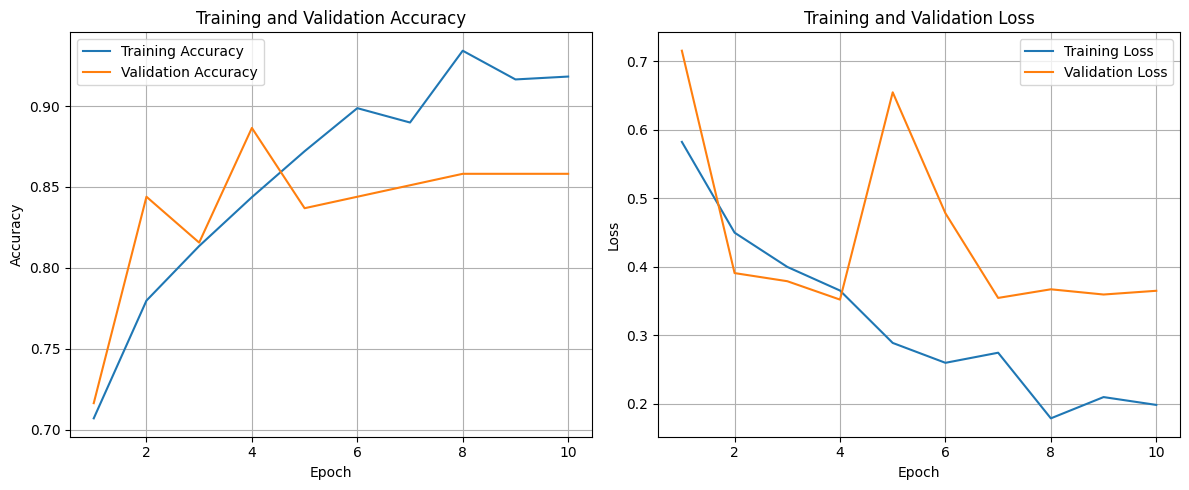

In [ ]:
import matplotlib.pyplot as plt
import torch.optim as optim

# Embedded train_model function to ensure correct definition is used
def train_model(model, train_loader, val_loader, num_epochs, learning_rate, device):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=learning_rate,
        weight_decay=1e-4
    )

    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.2, patience=2)

    best_val_accuracy = 0.0
    train_losses = []
    train_accuracies = []
    val_losses = []
    val_accuracies = []

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        correct_predictions = 0
        total_samples = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs.data, 1)
            total_samples += labels.size(0)
            correct_predictions += (predicted == labels).sum().item()

        epoch_train_loss = running_loss / len(train_loader.dataset)
        epoch_train_accuracy = correct_predictions / total_samples
        train_losses.append(epoch_train_loss)
        train_accuracies.append(epoch_train_accuracy)

        model.eval()
        val_running_loss = 0.0
        val_correct_predictions = 0
        val_total_samples = 0

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)

                val_running_loss += loss.item() * images.size(0)
                _, predicted = torch.max(outputs.data, 1)
                val_total_samples += labels.size(0)
                val_correct_predictions += (predicted == labels).sum().item()

        epoch_val_loss = val_running_loss / len(val_loader.dataset)
        epoch_val_accuracy = val_correct_predictions / val_total_samples
        val_losses.append(epoch_val_loss)
        val_accuracies.append(epoch_val_accuracy)

        scheduler.step(epoch_val_accuracy)

        if epoch_val_accuracy > best_val_accuracy:
            best_val_accuracy = epoch_val_accuracy

        print(f'   Epoch {epoch+1}/{num_epochs} - Train Loss: {epoch_train_loss:.4f}, Train Acc: {epoch_train_accuracy:.4f}, Val Loss: {epoch_val_loss:.4f}, Val Acc: {epoch_val_accuracy:.4f}')

    return best_val_accuracy, train_losses, train_accuracies, val_losses, val_accuracies, model

try:
    if 'best_hyperparams' in locals() and best_hyperparams:
        print(f"Retraining final model with: {best_hyperparams}")

        final_model = models.resnet18(pretrained=True)
        # Freeze all layers first
        for param in final_model.parameters():
            param.requires_grad = False

        # Unfreeze layer3, layer4 and fc for fine-tuning based on insights from tuning
        for name, param in final_model.named_parameters():
            if "layer4" in name or "layer3" in name:
                param.requires_grad = True

        # Add a Dropout layer inside the classification block
        final_model.fc = nn.Sequential(
            nn.Dropout(p=0.4),
            nn.Linear(final_model.fc.in_features, 2)
        )

        final_model = final_model.to(device)

        # Call the modified train_model function
        # Use best_hyperparams['num_epochs'] for num_epochs
        best_val_accuracy, train_losses, train_accuracies, val_losses, val_accuracies, trained_final_model = train_model(
            final_model,
            train_loader,
            val_loader,
            num_epochs=best_hyperparams['num_epochs'],
            learning_rate=best_hyperparams['learning_rate'],
            device=device
        )
        print("Final model retraining complete.")

        # Save the trained model
        torch.save(trained_final_model.state_dict(), '/content/best_tb_model.pth')
        print("Trained model saved to /content/best_tb_model.pth")

        # Plotting the results
        epochs_range = range(1, best_hyperparams['num_epochs'] + 1) # Updated epochs_range based on best_hyperparams

        plt.figure(figsize=(12, 5))

        plt.subplot(1, 2, 1)
        plt.plot(epochs_range, train_accuracies, label='Training Accuracy')
        plt.plot(epochs_range, val_accuracies, label='Validation Accuracy')
        plt.title('Training and Validation Accuracy')
        plt.xlabel('Epoch')
        plt.ylabel('Accuracy')
        plt.legend()
        plt.grid(True)

        plt.subplot(1, 2, 2)
        plt.plot(epochs_range, train_losses, label='Training Loss')
        plt.plot(epochs_range, val_losses, label='Validation Loss')
        plt.title('Training and Validation Loss')
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.legend()
        plt.grid(True)

        plt.tight_layout()
        plt.show()

    else:
        print("Error: 'best_hyperparams' is empty or not yet determined. Please run the hyperparameter tuning cell (d4577ce2) first.")
except NameError:
    print("Error: The variable 'best_hyperparams' is not defined. Please ensure you have executed the tuning cell (d4577ce2) before running this retraining cell.")

In [ ]:
import shutil
import os

# Define the source path of the saved model
source_model_path = '/content/best_tb_model.pth'

# Define the destination path in Google Drive
# Make sure the directory exists before copying
drive_save_dir = '/content/drive/MyDrive/TB_Model_Checkpoints'
os.makedirs(drive_save_dir, exist_ok=True)

destination_model_path = os.path.join(drive_save_dir, 'best_tb_model_final.pth')

# Copy the file to Google Drive
try:
    shutil.copy(source_model_path, destination_model_path)
    print(f"Model successfully saved to Google Drive at: {destination_model_path}")
except FileNotFoundError:
    print(f"Error: Source model file not found at {source_model_path}.")
except Exception as e:
    print(f"An error occurred while saving the model to Google Drive: {e}")


In [ ]:
pip install gradio

### 8. Validate with a Sample Image

### Generating a Detailed Validation Table

In [ ]:
import pandas as pd
import torch

# Ensure the model is in evaluation mode and on the correct device
trained_final_model.eval()
trained_final_model.to(device)

# Prepare lists to store results
image_ids = []
actual_labels = []
predicted_labels = []
confidence_scores = []

# Iterate through the validation dataset
with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        outputs = trained_final_model(images)
        probabilities = torch.softmax(outputs, dim=1)

        # Get predicted class and confidence
        conf, preds = torch.max(probabilities, 1)

        # Map image IDs from val_df
        # This part requires linking back to the original dataframe
        # We'll need to manually track which images correspond to which batch indices
        # For simplicity for now, we'll use a placeholder for image_id or assume sequential processing

        # Retrieve original image IDs from val_df based on the current batch's indices
        # This is a bit tricky as DataLoader shuffles. We need to get the original indices from val_dataset
        current_batch_indices = val_loader.sampler.indices[val_loader.batch_sampler.sampler.first_sample_index:val_loader.batch_sampler.sampler.first_sample_index + len(images)] if hasattr(val_loader.sampler, 'indices') else range(len(images))

        # Correct way to get image IDs from the dataset for the current batch
        batch_image_ids = [val_dataset.dataframe.iloc[i]['id'] for i in current_batch_indices]

        image_ids.extend(batch_image_ids)
        actual_labels.extend(labels.cpu().numpy())
        predicted_labels.extend(preds.cpu().numpy())
        confidence_scores.extend(conf.cpu().numpy())

# Create a DataFrame from the collected results
validation_table_df = pd.DataFrame({
    'Image ID': image_ids,
    'Actual Label': actual_labels,
    'Predicted Label': predicted_labels,
    'Confidence': confidence_scores
})

# Map numerical labels to descriptive class names for better readability
class_names = {0: 'Normal', 1: 'Tuberculosis'}
validation_table_df['Actual Label'] = validation_table_df['Actual Label'].map(class_names)
validation_table_df['Predicted Label'] = validation_table_df['Predicted Label'].map(class_names)

print("Validation Table (First 10 entries):")
display(validation_table_df.head(10))


This table provides a detailed view of how the model performed on individual images within the validation set, showing the model's prediction and its confidence for each case. You can further analyze this table to identify patterns in correct/incorrect classifications or explore specific cases.

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt

# Path to the sample image provided by the user
sample_image_path = '/content/Screenshot 2026-07-15 225318.png'

# Load the image
try:
    sample_image = Image.open(sample_image_path)
    print(f"Successfully loaded image: {sample_image_path}")

    # Display the image
    plt.imshow(sample_image)
    plt.title('Sample Image for Validation')
    plt.axis('off')
    plt.show()

    # Make a prediction using the predict_image function defined for Gradio
    if 'predict_image' in locals():
        prediction_result = predict_image(sample_image)
        print(f"Prediction for sample image: {prediction_result}")
    else:
        print("Error: The 'predict_image' function is not defined. Please ensure the Gradio setup cell (a1fcd229) was executed correctly.")

except FileNotFoundError:
    print(f"Error: Sample image not found at {sample_image_path}. Please check the path.")
except Exception as e:
    print(f"An error occurred while processing the sample image: {e}")

In [ ]:
import gradio as gr
import torch
import torchvision.transforms as transforms
from PIL import Image
import torchvision.models as models
import torch.nn as nn

# Ensure device is defined (it should be from previous cells)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Load the best trained model (architecture and state_dict)
def load_model(model_path='/content/best_tb_model.pth'):
    # Re-instantiate the model architecture
    loaded_model = models.resnet18(pretrained=True)
    for param in loaded_model.parameters():
        param.requires_grad = False

    # Unfreeze layer3, layer4 and fc
    for name, param in loaded_model.named_parameters():
        if "layer4" in name or "layer3" in name:
            param.requires_grad = True

    loaded_model.fc = nn.Sequential(
        nn.Dropout(p=0.4),
        nn.Linear(loaded_model.fc.in_features, 2)
    )

    loaded_model.load_state_dict(torch.load(model_path, map_location=device))
    loaded_model = loaded_model.to(device)
    loaded_model.eval() # Set to evaluation mode
    return loaded_model

# Load the model
try:
    final_trained_model = load_model()
    print("Model loaded successfully for interface.")
except Exception as e:
    print(f"Error loading model: {e}. Please ensure the model was trained and saved correctly.")
    final_trained_model = None # Indicate that model loading failed


# Define the prediction function for Gradio
def predict_image(image: Image.Image):
    if final_trained_model is None:
        return "Error: Model not loaded."

    # Apply the same validation transformations as during training
    val_transforms = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.Grayscale(num_output_channels=3),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

    image = val_transforms(image).unsqueeze(0).to(device) # Add batch dimension and move to device

    with torch.no_grad():
        outputs = final_trained_model(image)
        probabilities = torch.softmax(outputs, dim=1)
        _, predicted = torch.max(outputs, 1)

    # Map the predicted label to a meaningful class name
    class_names = ["Normal", "Tuberculosis"]
    predicted_class = class_names[predicted.item()]
    confidence = probabilities[0][predicted.item()].item()

    return f"Prediction: {predicted_class} (Confidence: {confidence:.2f})"

# Create the Gradio interface
if final_trained_model is not None:
    interface = gr.Interface(
        fn=predict_image,
        inputs=gr.Image(type="pil", label="Upload Chest X-ray Image"),
        outputs="text",
        title="Chest X-ray Tuberculosis Prediction",
        description="Upload a chest X-ray image to get a prediction for Tuberculosis."
    )

    interface.launch(debug=True, share=True)
else:
    print("Gradio interface cannot be launched because the model failed to load.")


In [ ]:
import torchvision.models as models
import torch.nn as nn
import torch
import os
import pandas as pd
import glob
from PIL import Image
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
from sklearn.model_selection import train_test_split
import zipfile
import torch.optim as optim

# --- 1. Infrastructure Setup ---
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# --- 2. Helper Function for Training ---
def train_model(model, train_loader, val_loader, num_epochs, learning_rate, device):
    criterion = nn.CrossEntropyLoss()
    # FIX: Added L2 Regularization (weight_decay=1e-4) to penalize large weights and stop overfitting
    optimizer = optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=learning_rate,
        weight_decay=1e-4
    )

    # FIX: Adding a learning rate scheduler to lower the learning rate dynamically when validation stalls
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.2, patience=2)

    best_val_accuracy = 0.0

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        correct_predictions = 0
        total_samples = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs.data, 1)
            total_samples += labels.size(0)
            correct_predictions += (predicted == labels).sum().item()

        epoch_train_loss = running_loss / len(train_loader.dataset)
        epoch_train_accuracy = correct_predictions / total_samples

        model.eval()
        val_running_loss = 0.0
        val_correct_predictions = 0
        val_total_samples = 0

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)

                val_running_loss += loss.item() * images.size(0)
                _, predicted = torch.max(outputs.data, 1)
                val_total_samples += labels.size(0)
                val_correct_predictions += (predicted == labels).sum().item()

        epoch_val_loss = val_running_loss / len(val_loader.dataset)
        epoch_val_accuracy = val_correct_predictions / val_total_samples

        # Step the scheduler based on validation accuracy performance
        scheduler.step(epoch_val_accuracy)

        if epoch_val_accuracy > best_val_accuracy:
            best_val_accuracy = epoch_val_accuracy

        print(f'   Epoch {epoch+1}/{num_epochs} - Train Loss: {epoch_train_loss:.4f}, Train Acc: {epoch_train_accuracy:.4f}, Val Loss: {epoch_val_loss:.4f}, Val Acc: {epoch_val_accuracy:.4f}')

    return best_val_accuracy

# --- 3. Data Re-initialization ---
if 'train_loader' not in locals() or 'val_loader' not in locals():
    print("Re-initializing data pipeline...")
    dataset_base_path = '/content/tb_dataset/'
    zip_path = '/content/drive/MyDrive/TB PROJECT/Chest X-ray Dataset for Tuberculosis Segmentation.zip'
    if not os.path.exists(dataset_base_path):
        os.makedirs(dataset_base_path, exist_ok=True)
        with zipfile.ZipFile(zip_path, 'r') as zip_ref: zip_ref.extractall(dataset_base_path)

    chest_xray_image_dir = os.path.join(dataset_base_path, 'Chest-X-Ray', 'Chest-X-Ray', 'image')
    metadata_df = pd.read_csv(os.path.join(dataset_base_path, 'MetaData.csv'))
    image_paths = glob.glob(os.path.join(chest_xray_image_dir, '*.png'))
    image_df = pd.DataFrame({'path': image_paths})
    image_df['id'] = image_df['path'].apply(lambda x: int(os.path.basename(x).replace('.png', '')))
    data_df = pd.merge(image_df, metadata_df, on='id', how='left')
    train_df, val_df = train_test_split(data_df, test_size=0.2, random_state=42, stratify=data_df['ptb'])

    # FIX: Enhanced data augmentation specifically tailored for structure-sensitive chest X-rays
    train_transforms = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(15),    # Increased rotation flexibility
        transforms.RandomAffine(degrees=0, translate=(0.05, 0.05)), # Simulates varying patient positions
        transforms.Grayscale(num_output_channels=3),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

    val_transforms = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.Grayscale(num_output_channels=3),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

    class ChestXRayDataset(Dataset):
        def __init__(self, dataframe, transform=None):
            self.dataframe = dataframe
            self.transform = transform
        def __len__(self): return len(self.dataframe)
        def __getitem__(self, idx):
            img_path = self.dataframe.iloc[idx]['path']
            image = Image.open(img_path).convert('L')
            label = self.dataframe.iloc[idx]['ptb']
            if self.transform: image = self.transform(image)
            return image, label

    train_loader = DataLoader(ChestXRayDataset(train_df, transform=train_transforms), batch_size=32, shuffle=True)
    val_loader = DataLoader(ChestXRayDataset(val_df, transform=val_transforms), batch_size=32, shuffle=False)

# --- 4. Hyperparameter Tuning ---
# FIX: Lowered learning rates. 0.001 is too high when unfreezing ResNet convolutional layers.
learning_rates = [0.0003, 0.0001, 0.00003]
num_epochs_options = [10, 15, 20]
best_hyperparams = {}
best_accuracy_overall = 0.0

print(f"Starting hyperparameter tuning on {device}...")

for lr in learning_rates:
    for epochs in num_epochs_options:
        print(f"\n>>> Testing LR: {lr}, Epochs: {epochs}")

        # Use updated Weights API pattern to avoid deprecation warnings
        tuned_model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

        # Freeze initial layers
        for param in tuned_model.parameters():
            param.requires_grad = False

        # FIX: Unfreeze ONLY layer4. Unfreezing layer3 + layer4 simultaneously creates too many
        # trainable parameters for small medical datasets, causing the immediate overfitting you saw.
        for name, param in tuned_model.named_parameters():
            if "layer4" in name:
                param.requires_grad = True

        # FIX: Add a Dropout layer inside the classification block to break feature dependency
        tuned_model.fc = nn.Sequential(
            nn.Dropout(p=0.4),
            nn.Linear(tuned_model.fc.in_features, 2)
        )

        tuned_model = tuned_model.to(device)

        current_accuracy = train_model(tuned_model, train_loader, val_loader, epochs, lr, device)

        if current_accuracy > best_accuracy_overall:
            best_accuracy_overall = current_accuracy
            best_hyperparams = {'learning_rate': lr, 'num_epochs': epochs}
            print(f"   New Best! Accuracy: {best_accuracy_overall:.4f}")

print(f"\nTuning complete! Best: {best_hyperparams} with Acc: {best_accuracy_overall:.4f}")

Re-initializing data pipeline...
Starting hyperparameter tuning on cuda...

>>> Testing LR: 0.0003, Epochs: 10
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 168MB/s]


   Epoch 1/10 - Train Loss: 0.6228, Train Acc: 0.6980, Val Loss: 0.5388, Val Acc: 0.7376
   Epoch 2/10 - Train Loss: 0.4735, Train Acc: 0.7833, Val Loss: 0.4933, Val Acc: 0.7730
   Epoch 3/10 - Train Loss: 0.4103, Train Acc: 0.8171, Val Loss: 0.4000, Val Acc: 0.8440
   Epoch 4/10 - Train Loss: 0.3744, Train Acc: 0.8242, Val Loss: 0.4823, Val Acc: 0.7801
   Epoch 5/10 - Train Loss: 0.3257, Train Acc: 0.8437, Val Loss: 0.4614, Val Acc: 0.8298
   Epoch 6/10 - Train Loss: 0.3213, Train Acc: 0.8739, Val Loss: 0.3370, Val Acc: 0.8723
   Epoch 7/10 - Train Loss: 0.2892, Train Acc: 0.8810, Val Loss: 0.3327, Val Acc: 0.8865
   Epoch 8/10 - Train Loss: 0.2728, Train Acc: 0.8828, Val Loss: 0.3235, Val Acc: 0.8936
   Epoch 9/10 - Train Loss: 0.2758, Train Acc: 0.8917, Val Loss: 0.4393, Val Acc: 0.8440
   Epoch 10/10 - Train Loss: 0.2530, Train Acc: 0.8899, Val Loss: 0.4472, Val Acc: 0.8227
   New Best! Accuracy: 0.8936

>>> Testing LR: 0.0003, Epochs: 15
   Epoch 1/15 - Train Loss: 0.6128, Train A